In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import (
    accuracy_score ,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer 
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder

from sklearn import set_config


In [54]:
set_config(transform_output='pandas')

## Load Data

In [55]:
df = pd.read_csv("../../data/cleaned_heart_disease.csv")
df.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,max_hr,exercise_angina,old_peak,st_slope,heartdisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              918 non-null    int64  
 1   sex              918 non-null    object 
 2   chestpaintype    918 non-null    object 
 3   restingbp        918 non-null    int64  
 4   cholesterol      918 non-null    int64  
 5   fastingbs        918 non-null    int64  
 6   restingecg       918 non-null    object 
 7   max_hr           918 non-null    int64  
 8   exercise_angina  918 non-null    object 
 9   old_peak         918 non-null    float64
 10  st_slope         918 non-null    object 
 11  heartdisease     918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## split the data

In [57]:
x = df.drop('heartdisease', axis=1)
y = df['heartdisease']

X_train,X_test,Y_train,Y_test =  train_test_split(x,y , stratify=y , random_state= 42, test_size=0.2)

In [58]:
print('X_train: ', X_train.shape)
print('X_test: ', X_test.shape)
print('Y_train: ', Y_train.shape)
print('Y_test: ', Y_test.shape)

X_train:  (734, 11)
X_test:  (184, 11)
Y_train:  (734,)
Y_test:  (184,)


In [59]:
Y_test.value_counts(normalize=True)

heartdisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64

In [60]:
Y_train.value_counts(normalize=True)

heartdisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

## Define categorical transformer

In [61]:
category_transformer =  ColumnTransformer(
    [
       ( 'cat_encoder',
        OneHotEncoder(sparse_output=False , drop='if_binary'),
        ['sex','chestpaintype', 'restingecg', 'exercise_angina','st_slope' ],
        )
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

###  Define Utility functions and Tables

In [62]:
def get_errors(model, X, y):
    """Computes the error metrics for evaluating a classification model."""

    preds = model.predict(X)
    accuracy = accuracy_score(y, preds)
    recall = recall_score(y, preds)
    precision = precision_score(y, preds, zero_division=0.0)
    return {"accuracy": accuracy, "recall": recall, "precision": precision}


def get_avg_cv_errors(cv_result):
    """Get the average value of the error metrics from the cross validation result."""

    return {
        "accuracy": cv_result["test_accuracy"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "precision": cv_result["test_precision"].mean(),
    }


def plot_confusion_matrix(model, model_name, X, y, split="test"):
    """Plot the confusion matrix of a classification model."""

    ConfusionMatrixDisplay.from_estimator(model, X, y)
    plt.title(f"Confusion Matrix of {model_name} Model [{split.title()} Set]")


def log_error(model_name, errors, eval_set, perf_df):
    """Store the performance metrics of a model."""

    cols = [eval_set + "_" + err for err in ("accuracy", "recall", "precision")]
    perf_df.loc[model_name, cols] = list(errors)

In [63]:
perf_df = pd.DataFrame(
    columns=[
        "train_accuracy",
        "train_recall",
        "train_precision",
        "cv_accuracy",
        "cv_recall",
        "cv_precision",
        "test_accuracy",
        "test_recall",
        "test_precision"
    ]
)

perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision


## Build  and Evaluate baseline model 

In [64]:
base_model = DummyClassifier()
base_model.fit(X_train,Y_train)

,strategy,'prior'
,random_state,None
,constant,None


In [65]:
base_train_pred = base_model.predict(X_train)

In [66]:
base_train_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [67]:
# Evaluate train model

base_train_error = get_errors(base_model,X_train,Y_train)
base_train_error

{'accuracy': 0.553133514986376, 'recall': 1.0, 'precision': 0.553133514986376}

In [68]:
# Log train error
log_error("Base Model", base_train_error.values(), "train", perf_df)

In [69]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,NaN,NaN,NaN,NaN,NaN,NaN


#### Get cross val error 

In [70]:
base_cv_error = cross_validate(base_model, X_train,Y_train, scoring=get_errors, cv=5)
base_cv_error

{'fit_time': array([0.00200415, 0.        , 0.        , 0.0023582 , 0.00200438]),
 'score_time': array([0.00601482, 0.00916648, 0.00918961, 0.0090189 , 0.006181  ]),
 'test_accuracy': array([0.55782313, 0.55102041, 0.55102041, 0.55102041, 0.55479452]),
 'test_recall': array([1., 1., 1., 1., 1.]),
 'test_precision': array([0.55782313, 0.55102041, 0.55102041, 0.55102041, 0.55479452])}

In [71]:
base_avg_cv_error = get_avg_cv_errors(base_cv_error)
base_avg_cv_error

{'accuracy': np.float64(0.5531357748578885),
 'recall': np.float64(1.0),
 'precision': np.float64(0.5531357748578885)}

In [72]:
log_error("Base Model",base_avg_cv_error.values(), "cv" , perf_df)

In [73]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,NaN,NaN,NaN


#### Evalute model on test set 

In [74]:
base_test_pred = base_model.predict(X_test)
base_test_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [75]:
base_test_error = get_errors(base_model,X_test,Y_test)
base_test_error

{'accuracy': 0.5543478260869565,
 'recall': 1.0,
 'precision': 0.5543478260869565}

In [76]:
log_error('Base Model', base_test_error.values(),"test",perf_df)

In [77]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348


## Base Model Confusion Matrix

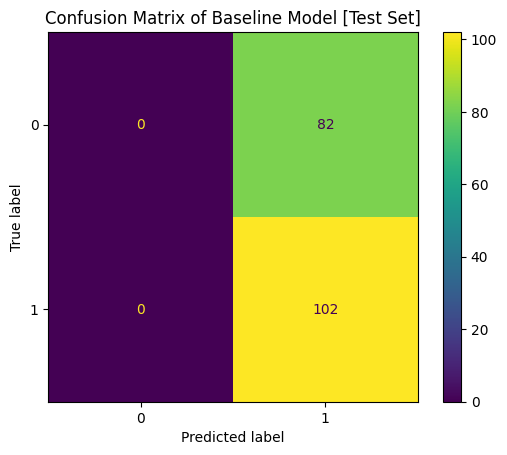

In [78]:
plot_confusion_matrix(base_model,'Baseline',X_test,Y_test)

## Logistics Model

In [79]:
lg_model = LogisticRegression(max_iter=2000)

In [80]:
lg_pipeline = make_pipeline(category_transformer,lg_model)

#### Train model 

In [81]:
lg_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evalute mdoel

In [82]:
lg_train_pred = lg_pipeline.predict(X_train)

In [83]:
lg_train_error =  get_errors(lg_pipeline,X_train,Y_train)
lg_train_error

{'accuracy': 0.8583106267029973,
 'recall': 0.8842364532019704,
 'precision': 0.8629807692307693}

#### Get cross validation result

In [84]:
lg_cv_error =  cross_validate(lg_pipeline, X_train,Y_train,cv=5, scoring=get_errors)
lg_cv_error

{'fit_time': array([0.37081027, 0.46297956, 0.37589002, 0.33034348, 0.46449876]),
 'score_time': array([0.01966882, 0.01893926, 0.01751065, 0.01783013, 0.01868081]),
 'test_accuracy': array([0.88435374, 0.87755102, 0.85034014, 0.83673469, 0.80136986]),
 'test_recall': array([0.92682927, 0.87654321, 0.85185185, 0.85185185, 0.85185185]),
 'test_precision': array([0.87356322, 0.89873418, 0.87341772, 0.85185185, 0.80232558])}

In [85]:
lg_avg_cv_errors = get_avg_cv_errors(lg_cv_error)
lg_avg_cv_errors

{'accuracy': np.float64(0.8500698909700868),
 'recall': np.float64(0.8717856067449563),
 'precision': np.float64(0.8599785100744365)}

#### Evaluate model on test set 

In [86]:
lg_test_errors = get_errors(lg_pipeline, X_test,Y_test)
lg_test_errors

{'accuracy': 0.8858695652173914,
 'recall': 0.9313725490196079,
 'precision': 0.8715596330275229}

#### log errors 

In [87]:
log_error("Lg_Model", lg_train_error.values(),"train", perf_df)
log_error("Lg_Model", lg_avg_cv_errors.values(),"cv", perf_df)
log_error("Lg_Model", lg_test_errors.values(),"test", perf_df)

In [88]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156


### Lg Model confusion matrix

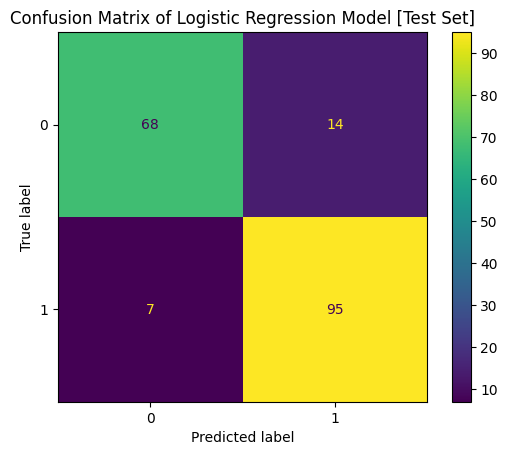

In [89]:
plot_confusion_matrix(lg_pipeline,"Logistic Regression",X_test,Y_test)

### Decision Tree Model 

In [90]:
dt_model = DecisionTreeClassifier(random_state=42)

In [91]:
dt_pipeline = make_pipeline(category_transformer,dt_model)
dt_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Handle overfitting

In [92]:
dt_pipeline[-1].get_depth()

14

In [93]:
param_grid = {"decisiontreeclassifier__max_depth":range(2,14)}

grid_search_cv =  GridSearchCV(
    dt_pipeline, param_grid=param_grid,
    scoring=["accuracy","recall","precision"] ,  refit='recall',
    return_train_score=True
)
grid_search_cv.fit(X_train,Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'decisiontreeclassifier__max_depth': range(2, 14)}"
,scoring,"['accuracy', 'recall', ...]"
,n_jobs,None
,refit,'recall'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('cat_encoder', ...)]"


In [94]:
cv_result = pd.DataFrame(grid_search_cv.cv_results_)
cv_result.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_decisiontreeclassifier__max_depth,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,mean_test_precision,std_test_precision,rank_test_precision,split0_train_precision,split1_train_precision,split2_train_precision,split3_train_precision,split4_train_precision,mean_train_precision,std_train_precision
0,0.014005,0.004043,0.013780,0.002978,2,{'decisiontreeclassifier__max_depth': 2},0.884354,0.823129,0.836735,0.802721,...,0.831995,0.031357,9,0.822289,0.827485,0.826471,0.834808,0.845921,0.831395,0.008308
1,0.010690,0.006912,0.012667,0.002507,3,{'decisiontreeclassifier__max_depth': 3},0.884354,0.843537,0.870748,0.789116,...,0.852289,0.054877,1,0.882353,0.885714,0.878981,0.829268,0.881988,0.871661,0.021303
2,0.011118,0.003911,0.009757,0.008236,4,{'decisiontreeclassifier__max_depth': 4},0.863946,0.843537,0.836735,0.789116,...,0.850374,0.034033,2,0.897106,0.886154,0.868035,0.897196,0.898462,0.889391,0.011570
3,0.014361,0.003485,0.017795,0.004005,5,{'decisiontreeclassifier__max_depth': 5},0.836735,0.809524,0.843537,0.823129,...,0.832505,0.028073,7,0.902077,0.878187,0.868132,0.900293,0.915152,0.892768,0.017111
4,0.010800,0.005278,0.018048,0.006648,6,{'decisiontreeclassifier__max_depth': 6},0.823129,0.823129,0.863946,0.809524,...,0.844406,0.029159,3,0.940625,0.949045,0.914956,0.947531,0.964286,0.943288,0.016136


In [95]:
cv_cols = [
    "param_decisiontreeclassifier__max_depth",
    "mean_test_recall",
    "mean_test_accuracy",
    "mean_test_precision",
    "std_test_recall",
    "mean_train_recall",
    "std_train_recall",
    "rank_test_recall",
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]

In [96]:
cv_results_subset = cv_result[cv_cols].sort_values(["rank_test_recall", "std_test_recall"])

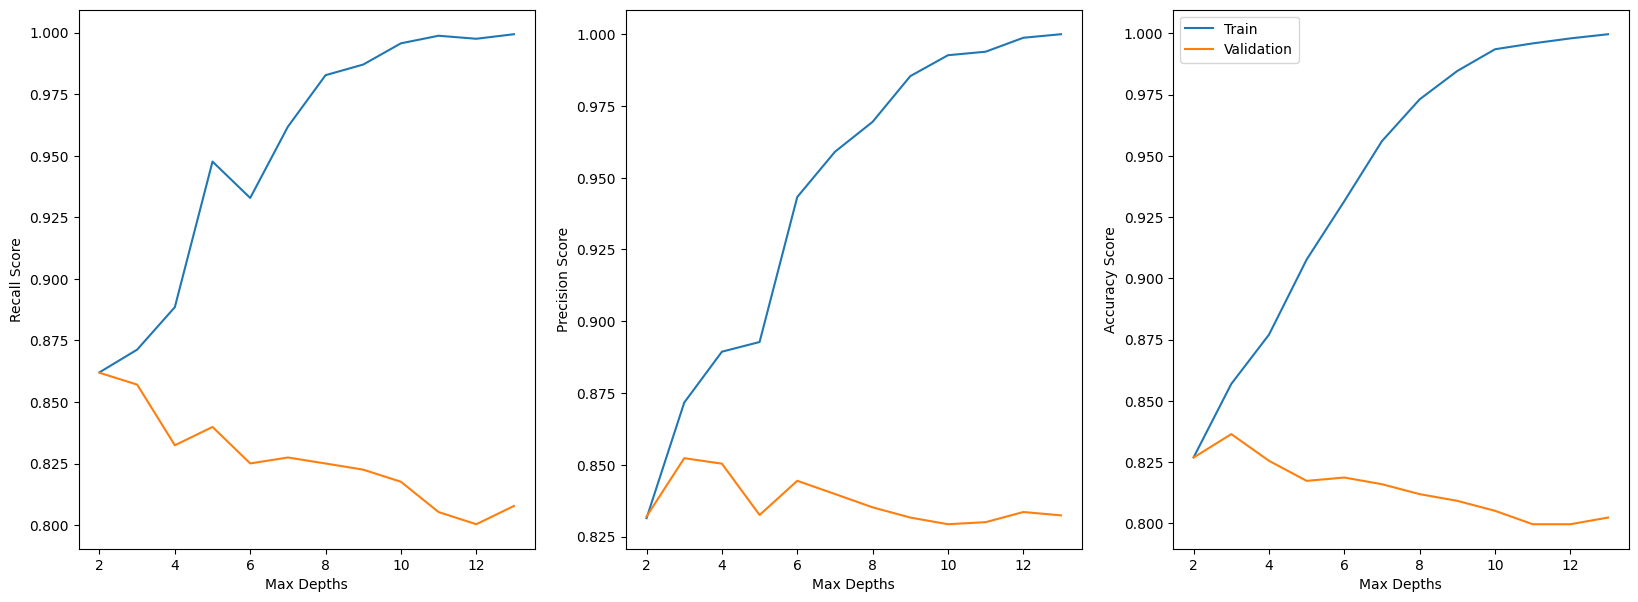

In [97]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_recall"], label="Train")
ax1.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_recall"], label="Validation")
ax1.set_xlabel("Max Depths")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_precision"], label="Train")
ax2.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_precision"], label="Validation")
ax2.set_xlabel("Max Depths")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_train_accuracy"], label="Train")
ax3.plot(cv_result["param_decisiontreeclassifier__max_depth"], cv_result["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Max Depths")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [98]:
cv_results_subset.set_index("param_decisiontreeclassifier__max_depth").loc[[2,3,4,5]]

,mean_test_recall,mean_test_accuracy,mean_test_precision,std_test_recall,mean_train_recall,std_train_recall,rank_test_recall,mean_train_accuracy,mean_train_precision
param_decisiontreeclassifier__max_depth,,,,,,,,,
2,0.861879,0.826922,0.831995,0.041154,0.862057,0.010368,1,0.826972,0.831395
3,0.857061,0.836455,0.852289,0.024555,0.871282,0.037505,2,0.856945,0.871661
4,0.832430,0.825571,0.850374,0.035744,0.888530,0.016470,4,0.877040,0.889391
5,0.839868,0.817380,0.832505,0.028320,0.947654,0.014716,3,0.907696,0.892768


 We will choose 3 as the best max depth , because it more balance for recall and precision

#### Retain the model with max depth of 3

In [99]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [100]:
dt_pipeline = make_pipeline(category_transformer,dt_model)
dt_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evaluate the training set

In [101]:
dt_train_errors = get_errors(dt_pipeline,X_train,Y_train)
dt_train_errors

{'accuracy': 0.8542234332425068,
 'recall': 0.8448275862068966,
 'precision': 0.8863049095607235}

#### cross validate

In [102]:
dt_cv_errors = cross_validate(dt_pipeline, X_train,Y_train , cv=5 , scoring=get_errors ,  n_jobs=-1)
dt_avg_cv_errors = get_avg_cv_errors(dt_cv_errors)
dt_avg_cv_errors


{'accuracy': np.float64(0.8364551299972044),
 'recall': np.float64(0.8570611261668171),
 'precision': np.float64(0.8522887166565327)}

#### Test set

In [103]:
dt_test_errors = get_errors(dt_pipeline,X_test,Y_test)
dt_test_errors

{'accuracy': 0.8206521739130435,
 'recall': 0.7941176470588235,
 'precision': 0.8709677419354839}

In [104]:
log_error("Dt_Model", dt_train_errors.values(), "train", perf_df)
log_error("Dt_Model", dt_avg_cv_errors.values(), "cv", perf_df)
log_error("Dt_Model", dt_test_errors.values(), "test", perf_df)

In [105]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968


### confusion matrix for DT

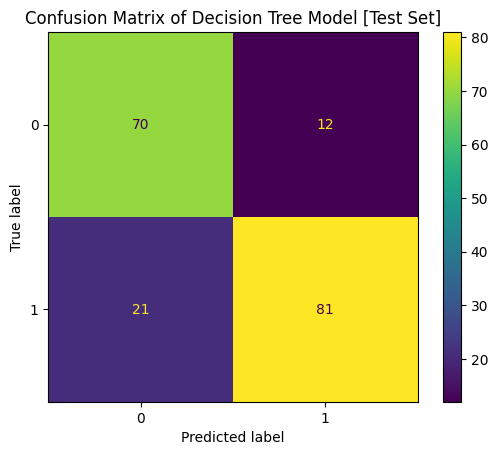

In [106]:
plot_confusion_matrix(dt_pipeline, "Decision Tree", X_test, Y_test)

## Random Forest

In [107]:
rf_model = RandomForestClassifier(max_depth=3 , random_state=42)

In [108]:
rf_pipeline = make_pipeline(category_transformer ,  rf_model)
rf_pipeline.fit(X_train,Y_train)

,steps,"[('columntransformer', ...), ('randomforestclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [109]:
rf_train_errors = get_errors(rf_pipeline, X_train, Y_train)
rf_train_errors

{'accuracy': 0.8623978201634878,
 'recall': 0.9088669950738916,
 'precision': 0.8521939953810623}

#### Cross validation 

In [110]:
rf_cv_results = cross_validate(rf_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
rf_avg_cv_errors = get_avg_cv_errors(rf_cv_results)
rf_avg_cv_errors

{'accuracy': np.float64(0.8541981176032056),
 'recall': np.float64(0.9087021981330924),
 'precision': np.float64(0.8408776121608847)}

#### Evaluate on test set 

In [111]:
rf_test_errors = get_errors(rf_pipeline, X_test, Y_test)
rf_test_errors

{'accuracy': 0.8315217391304348,
 'recall': 0.9019607843137255,
 'precision': 0.8141592920353983}

In [112]:
log_error("Rf_Model", rf_train_errors.values(), "train", perf_df)
log_error("Rf_Model", rf_avg_cv_errors.values(), "cv", perf_df)
log_error("Rf_Model", rf_test_errors.values(), "test", perf_df)

In [113]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159


### Plot Rf model Confusion matrix 

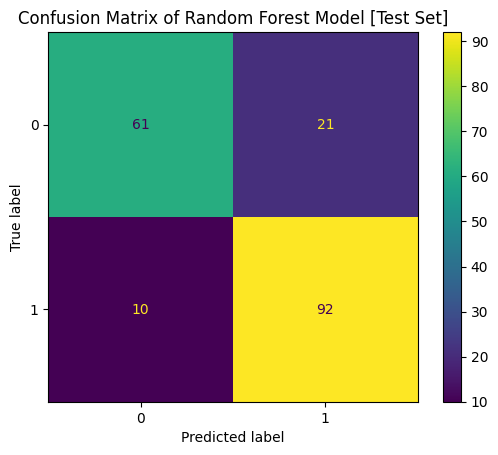

In [114]:
plot_confusion_matrix(rf_pipeline, "Random Forest", X_test, Y_test)

## Gradient Boosting 

In [115]:
gb_model = GradientBoostingClassifier(max_depth=3, random_state=42)

In [116]:
gb_pipeline = make_pipeline(category_transformer, gb_model)
gb_pipeline.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### Evaluate Model on trainig set 

In [117]:
gb_train_errors = get_errors(gb_pipeline, X_train, Y_train)
gb_train_errors

{'accuracy': 0.9536784741144414,
 'recall': 0.9679802955665024,
 'precision': 0.9492753623188406}

### Cross   Validation

In [118]:
cv_results = cross_validate(gb_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.8555493430248813),
 'recall': np.float64(0.8693465823547125),
 'precision': np.float64(0.8704280411963662)}

## Test set 

In [119]:
gb_test_errors = get_errors(gb_pipeline, X_test, Y_test)
gb_test_errors

{'accuracy': 0.8913043478260869,
 'recall': 0.9019607843137255,
 'precision': 0.9019607843137255}

## Log errors 

In [120]:
log_error("Gb_Model", gb_train_errors.values(), "train", perf_df)
log_error("Gb_Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Gb_Model", gb_test_errors.values(), "test", perf_df)

In [121]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159
Gb_Model,0.953678,0.96798,0.949275,0.855549,0.869347,0.870428,0.891304,0.901961,0.901961


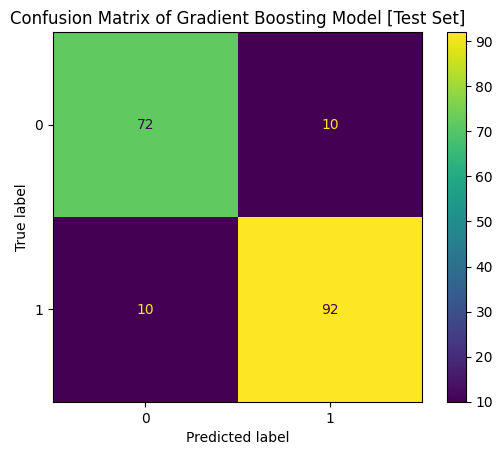

In [122]:
plot_confusion_matrix(gb_pipeline, "Gradient Boosting", X_test, Y_test)

### Find Optimal Learning Rate of Gradient Boosting 

In [118]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.01, 0.1, 10), 
              "gradientboostingclassifier__n_estimators":[100,200,300,500],
              "gradientboostingclassifier__min_samples_leaf":[1,2,3],
              "gradientboostingclassifier__max_depth":[2,3,4]
              }

grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"],
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'gradientboostingclassifier__learning_rate': array([0.01, ..., 0.09, 0.1 ]), 'gradientboostingclassifier__max_depth': [2, 3, ...], 'gradientboostingclassifier__min_samples_leaf': [1, 2, ...], 'gradientboostingclassifier__n_estimators': [100, 200, ...]}"
,scoring,"['accuracy', 'recall', ...]"
,n_jobs,-1
,refit,'recall'
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('cat_encoder', ...)]"


In [119]:
cv_results = pd.DataFrame(grid_search_cv.cv_results_)

In [126]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "param_gradientboostingclassifier__n_estimators",
    "param_gradientboostingclassifier__min_samples_leaf",
    "param_gradientboostingclassifier__max_depth",
    "mean_test_recall",
    "mean_test_precision",
    "mean_test_accuracy",
    "rank_test_recall",
    "mean_train_recall",
    
    
    "mean_train_accuracy",
    
    "mean_train_precision",
]
cv_results_subset = cv_results[cv_cols].sort_values(["rank_test_recall"])

In [134]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")[:30]

,param_gradientboostingclassifier__learning_rate,param_gradientboostingclassifier__n_estimators,param_gradientboostingclassifier__min_samples_leaf,param_gradientboostingclassifier__max_depth,mean_test_recall,mean_test_precision,mean_test_accuracy,rank_test_recall,mean_train_recall,mean_train_accuracy,mean_train_precision
20,0.01,100,3,3,0.908732,0.838948,0.852828,1,0.934726,0.875677,0.854591
1,0.01,200,1,2,0.906263,0.846188,0.856910,2,0.923022,0.871931,0.856720
5,0.01,200,2,2,0.906263,0.846188,0.856910,2,0.923022,0.871931,0.856720
16,0.01,100,2,3,0.906263,0.838575,0.851468,2,0.934108,0.875336,0.854515
9,0.01,200,3,2,0.906263,0.846188,0.856910,2,0.923022,0.871931,0.856720
17,0.01,200,2,3,0.886540,0.849747,0.850070,46,0.935956,0.894750,0.881312
21,0.01,200,3,3,0.886540,0.843505,0.845988,46,0.934104,0.894069,0.881603
22,0.01,300,3,3,0.886570,0.858139,0.855531,44,0.936572,0.908375,0.901677
13,0.01,200,1,3,0.886540,0.849747,0.850070,46,0.937187,0.895431,0.881447
18,0.01,300,2,3,0.886570,0.852358,0.851440,44,0.937802,0.909056,0.901807


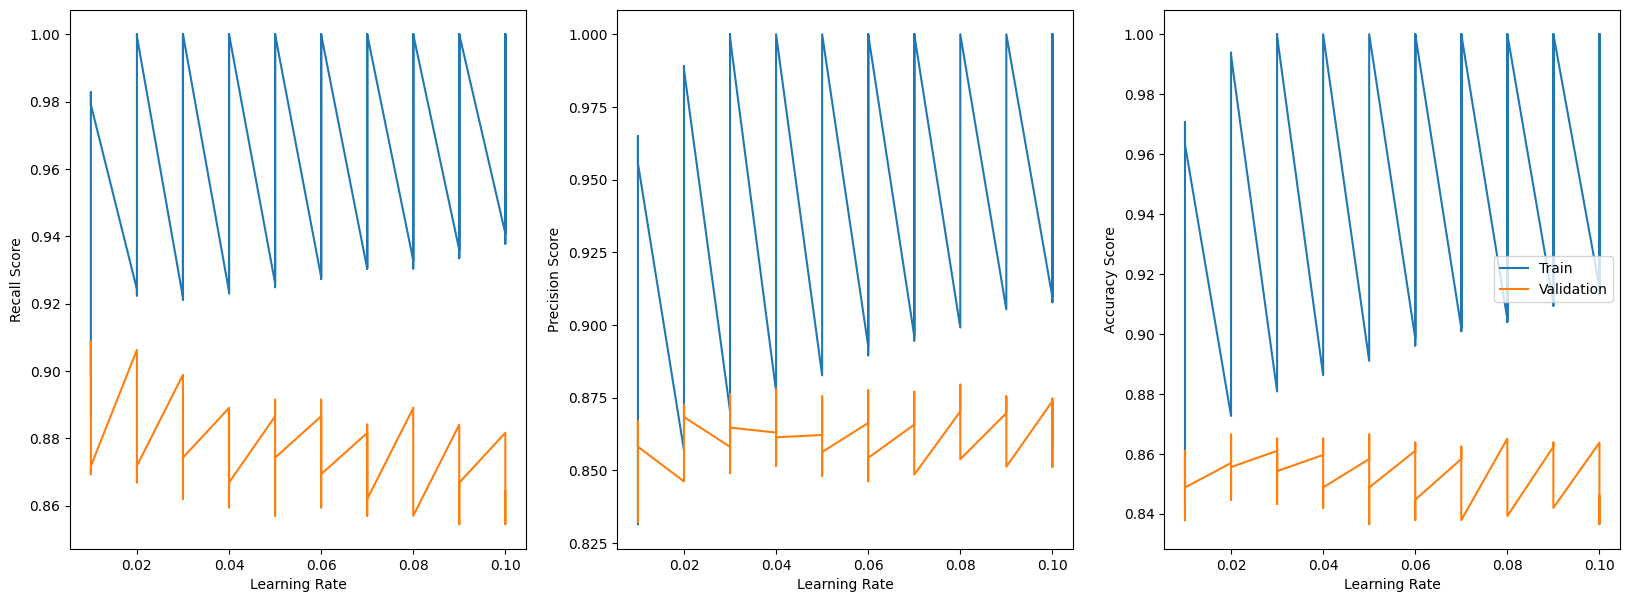

In [125]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_recall"], label="Train")
ax1.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_precision"], label="Train")
ax2.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_train_accuracy"], label="Train")
ax3.plot(cv_results["param_gradientboostingclassifier__learning_rate"], cv_results["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

### Retrain model using learning rate of 0.01, min_leaf 3 and n_estimator 100

In [135]:
gb_model_pretrain = GradientBoostingClassifier(max_depth=3, learning_rate=0.01, min_samples_leaf=3, n_estimators=100,  random_state=42)

In [136]:
gb_pipeline_pretrain = make_pipeline(category_transformer, gb_model_pretrain)
gb_pipeline_pretrain.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Evalaute on train set 

In [137]:
gb_pretrain_errors = get_errors(gb_pipeline_pretrain, X_train, Y_train)
gb_pretrain_errors

{'accuracy': 0.8719346049046321,
 'recall': 0.9384236453201971,
 'precision': 0.8466666666666667}

#### Cross Validate 

In [141]:
pretrain_cv_results = cross_validate(gb_pipeline_pretrain, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
pre_gb_avg_cv_errors = get_avg_cv_errors(pretrain_cv_results)
pre_gb_avg_cv_errors

{'accuracy': np.float64(0.8528282545895071),
 'recall': np.float64(0.9087323095453176),
 'precision': np.float64(0.8389479681482616)}

#### Test set 

In [142]:
pretrain_gb_test_errors = get_errors(gb_pipeline_pretrain, X_test, Y_test)
pretrain_gb_test_errors

{'accuracy': 0.842391304347826,
 'recall': 0.9019607843137255,
 'precision': 0.8288288288288288}

In [143]:
log_error("preOpt GB Model", gb_pretrain_errors.values(), "train", perf_df)
log_error("preOpt GB Model", pre_gb_avg_cv_errors.values(), "cv", perf_df)
log_error("preOpt GB Model", pretrain_gb_test_errors.values(), "test", perf_df)

In [144]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159
Gb_Model,0.953678,0.96798,0.949275,0.855549,0.869347,0.870428,0.891304,0.901961,0.901961
preOpt GB Model,0.871935,0.938424,0.846667,0.852828,0.908732,0.838948,0.842391,0.901961,0.828829


### Retrain model 

In [ ]:
param_grid = {"gradientboostingclassifier__learning_rate": np.linspace(0.001, 0.01, 10)}


grid_search_cv = GridSearchCV(
    gb_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "recall", "precision"],
    return_train_score=True,
    refit="recall",
    n_jobs=-1,
)
grid_search_cv.fit(X_train, Y_train)

In [76]:
cv_results2 = pd.DataFrame(grid_search_cv.cv_results_)

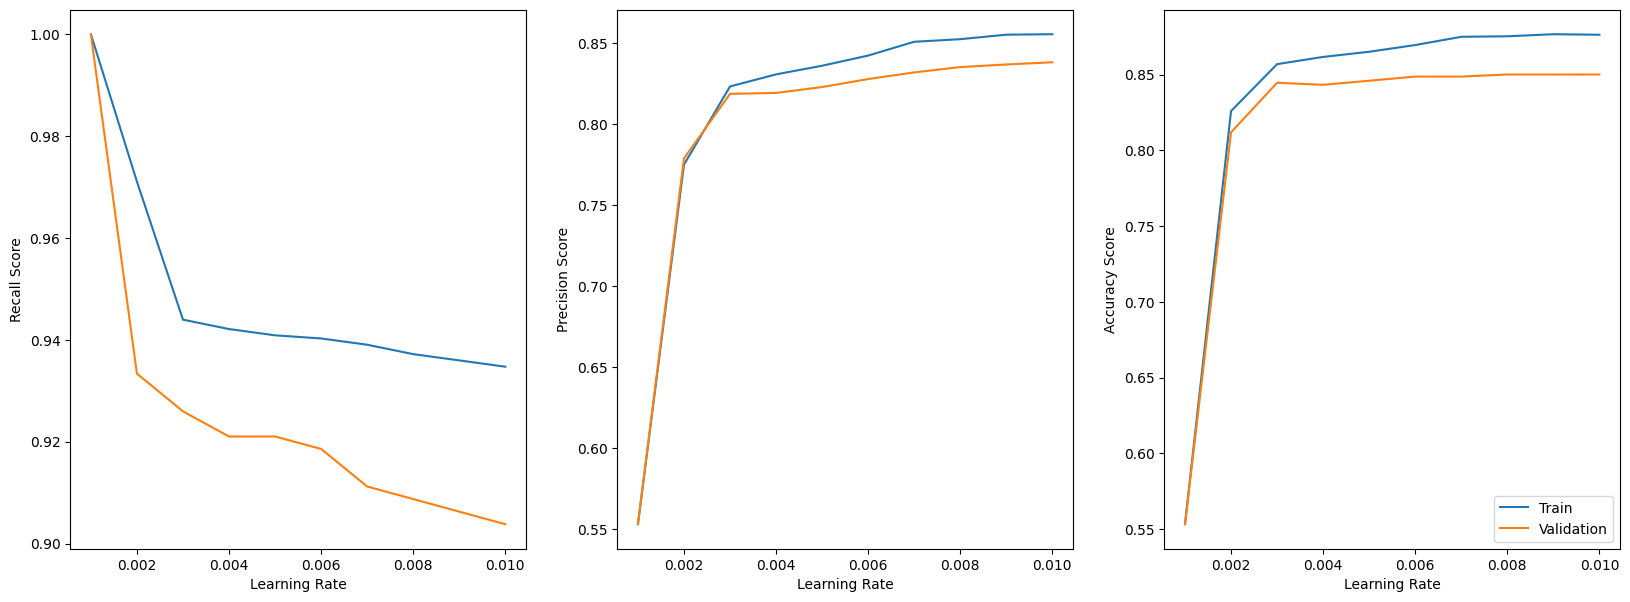

In [77]:
_, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_train_recall"], label="Train")
ax1.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_test_recall"], label="Validation")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Recall Score")

ax2.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_train_precision"], label="Train")
ax2.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_test_precision"], label="Validation")
ax2.set_xlabel("Learning Rate")
ax2.set_ylabel("Precision Score")

ax3.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_train_accuracy"], label="Train")
ax3.plot(cv_results2["param_gradientboostingclassifier__learning_rate"], cv_results2["mean_test_accuracy"], label="Validation")
ax3.set_xlabel("Learning Rate")
ax3.set_ylabel("Accuracy Score")
plt.legend();

In [78]:
cv_cols = [
    "param_gradientboostingclassifier__learning_rate",
    "mean_test_recall",
    "mean_train_recall",
    "rank_test_recall",
    "mean_test_accuracy",
    "mean_train_accuracy",
    "mean_test_precision",
    "mean_train_precision",
]
cv_results_subset = cv_results2[cv_cols].sort_values(["rank_test_recall"])

In [79]:
cv_results_subset.sort_values("param_gradientboostingclassifier__learning_rate")

,param_gradientboostingclassifier__learning_rate,mean_test_recall,mean_train_recall,rank_test_recall,mean_test_accuracy,mean_train_accuracy,mean_test_precision,mean_train_precision
0,0.001,1.000000,1.000000,1,0.553136,0.553134,0.553136,0.553134
1,0.002,0.933363,0.971066,2,0.811891,0.825955,0.778909,0.775093
2,0.003,0.925956,0.943958,3,0.844646,0.856948,0.818743,0.823336
3,0.004,0.921018,0.942112,4,0.843276,0.861712,0.819337,0.830793
4,0.005,0.921018,0.940881,4,0.845998,0.865119,0.822965,0.836121
5,0.006,0.918579,0.940266,6,0.848728,0.869548,0.827892,0.842400
6,0.007,0.911201,0.939035,7,0.848737,0.874996,0.832014,0.850904
7,0.008,0.908732,0.937189,8,0.850098,0.875336,0.835276,0.852511
8,0.009,0.906263,0.935958,9,0.850098,0.876699,0.836895,0.855283
9,0.010,0.903794,0.934724,10,0.850107,0.876359,0.838254,0.855566


### Retrain the model using learning rate of 0.004


In [146]:
gb_model_retrain = GradientBoostingClassifier(max_depth=3, learning_rate=0.004, random_state=42)

In [147]:
gb_pipeline_retrain = make_pipeline(category_transformer, gb_model_retrain)
gb_pipeline_retrain.fit(X_train, Y_train)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### Evaluate on training set 

In [148]:
gb_retrain_errors = get_errors(gb_pipeline_retrain, X_train, Y_train)
gb_retrain_errors

{'accuracy': 0.8596730245231607,
 'recall': 0.9408866995073891,
 'precision': 0.8286334056399133}

#### Cross Validation

In [149]:
retrain_cv_results = cross_validate(gb_pipeline_retrain, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5)
gb_avg_cv_errors = get_avg_cv_errors(retrain_cv_results)
gb_avg_cv_errors

{'accuracy': np.float64(0.8432764886776628),
 'recall': np.float64(0.9210177657332128),
 'precision': np.float64(0.819336802648774)}

#### Test set 

In [150]:
retrain_gb_test_errors = get_errors(gb_pipeline_retrain, X_test, Y_test)
retrain_gb_test_errors

{'accuracy': 0.8206521739130435,
 'recall': 0.9215686274509803,
 'precision': 0.7899159663865546}

#### log errors 

In [151]:
log_error("Opt GB Model", gb_retrain_errors.values(), "train", perf_df)
log_error("Opt GB Model", gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Opt GB Model", retrain_gb_test_errors.values(), "test", perf_df)

In [152]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159
Gb_Model,0.953678,0.96798,0.949275,0.855549,0.869347,0.870428,0.891304,0.901961,0.901961
preOpt GB Model,0.871935,0.938424,0.846667,0.852828,0.908732,0.838948,0.842391,0.901961,0.828829
Opt GB Model,0.859673,0.940887,0.828633,0.843276,0.921018,0.819337,0.820652,0.921569,0.789916


#### confusion matrix

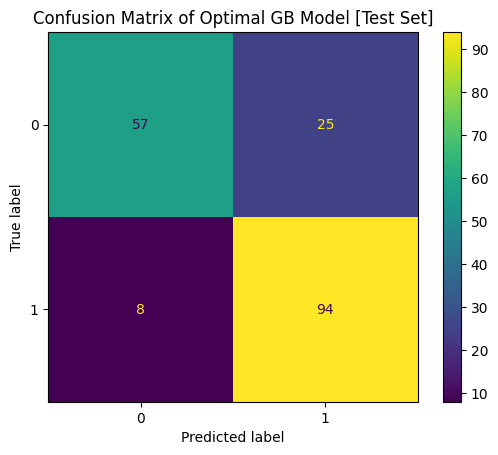

In [153]:
plot_confusion_matrix(gb_pipeline_retrain, "Optimal GB", X_test, Y_test)

### Add Kmeans features to GBmodel

In [186]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion

In [187]:
kmean_pipe = make_pipeline(
    category_transformer,
    StandardScaler(),
    KMeans(3, random_state=42)
)

In [188]:
feat_union = FeatureUnion(
    [
    ("base_feat", category_transformer),
    ("kmean_feat", kmean_pipe),
    ],
    verbose_feature_names_out = False

)

In [191]:
gb_kmeans_pipeline = make_pipeline(
    feat_union,
    gb_model
)

In [192]:
gb_kmeans_pipeline.fit(X_train,Y_train)

,steps,"[('featureunion', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformer_list,"[('base_feat', ...), ('kmean_feat', ...)]"
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,categories,'auto'
,drop,'if_binary'


#### Evaluate on Train set 

In [161]:
gb_km_train_errors = get_errors(gb_kmeans_pipeline, X_train, Y_train)
gb_km_train_errors

{'accuracy': 0.9591280653950953,
 'recall': 0.9679802955665024,
 'precision': 0.9585365853658536}

#### Evaluate on cross validation set 

In [163]:
km_cv_results = cross_validate(gb_kmeans_pipeline, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1)
km_gb_avg_cv_errors = get_avg_cv_errors(km_cv_results)
km_gb_avg_cv_errors

{'accuracy': np.float64(0.8309943155344328),
 'recall': np.float64(0.852122854561879),
 'precision': np.float64(0.8450993426092145)}

#### Evaluate on test set

In [166]:
gb_km_test_errors = get_errors(gb_kmeans_pipeline, X_test, Y_test)
gb_km_test_errors

{'accuracy': 0.8858695652173914,
 'recall': 0.8921568627450981,
 'precision': 0.900990099009901}

#### Log error 

In [167]:
log_error("Opt GB+KM Model", gb_km_train_errors.values(), "train", perf_df)
log_error("Opt GB+KM Model", km_gb_avg_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM Model", gb_km_test_errors.values(), "test", perf_df)

In [168]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159
Gb_Model,0.953678,0.96798,0.949275,0.855549,0.869347,0.870428,0.891304,0.901961,0.901961
preOpt GB Model,0.871935,0.938424,0.846667,0.852828,0.908732,0.838948,0.842391,0.901961,0.828829
Opt GB Model,0.859673,0.940887,0.828633,0.843276,0.921018,0.819337,0.820652,0.921569,0.789916
Opt GB+KM Model,0.959128,0.96798,0.958537,0.830994,0.852123,0.845099,0.88587,0.892157,0.90099


### confusion matrix 

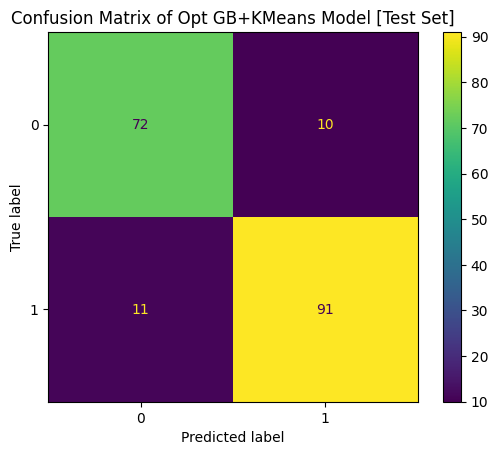

In [169]:
plot_confusion_matrix(gb_kmeans_pipeline, "Opt GB+KMeans", X_test, Y_test)

### Visualize Feature importance

In [170]:
feat_imps = pd.Series(
    gb_kmeans_pipeline[-1].feature_importances_,
    index=gb_kmeans_pipeline[-1].feature_names_in_,
).sort_values()

In [171]:
def clean_feats_name(feature):
    if "__" in feature:
        return feature[feature.index("__")+2:]
    return feature

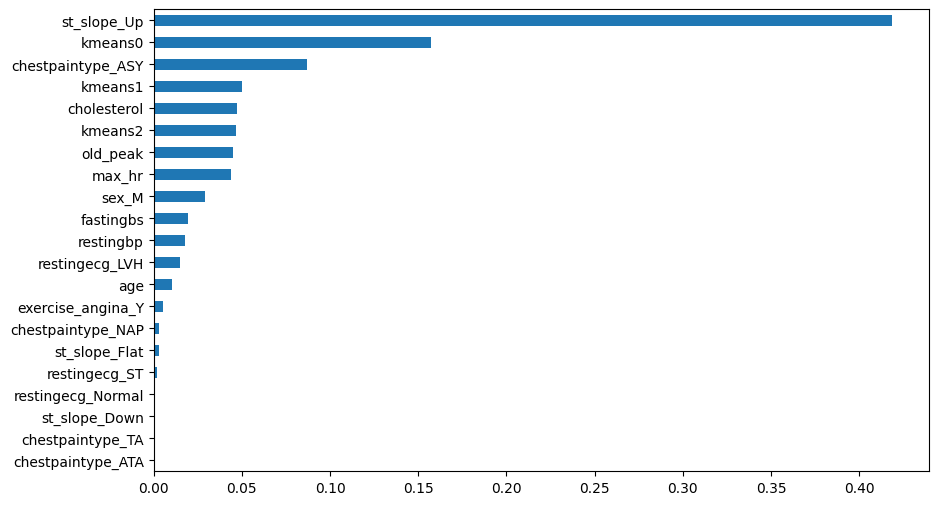

In [172]:
ax = feat_imps.plot(kind="barh", figsize=(10, 6))
ax.set_yticklabels(feat_imps.index.map(clean_feats_name));

#### Handle Class imbalance 

In [173]:
from sklearn.metrics import precision_recall_curve

In [174]:
precision, recall, thresholds = precision_recall_curve(Y_test, gb_kmeans_pipeline.predict_proba(X_test)[:, 1])

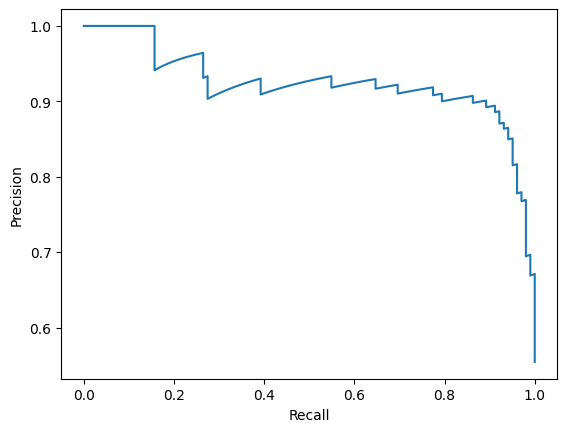

In [175]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision");

## Find optimal probality threshold

In [83]:
from sklearn.model_selection import TunedThresholdClassifierCV

In [ ]:
ttcv = TunedThresholdClassifierCV(gb_kmeans_pipeline, cv=5, n_jobs=-1)
ttcv.fit(X_train, Y_train)

,estimator,Pipeline(step...m_state=42))])
,scoring,'balanced_accuracy'
,response_method,'auto'
,thresholds,100
,cv,5
,refit,True
,n_jobs,-1
,random_state,None
,store_cv_results,False
,transformer_list,"[('base_feat', ...), ('kmean_feat', ...)]"
,n_jobs,None


### Get the error 

In [202]:
ttcv_train_error = get_errors(ttcv,X_train,Y_train)
ttcv_train_error

{'accuracy': 0.9564032697547684,
 'recall': 0.9482758620689655,
 'precision': 0.9722222222222222}

#### Evaluate with cross validation

In [203]:
ttcv_results = cross_validate(
    ttcv, X_train, Y_train, scoring=["accuracy", "precision", "recall"], cv=5, n_jobs=-1
)


In [204]:
ttcv_cv_errors = get_avg_cv_errors(ttcv_results)
ttcv_cv_errors

{'accuracy': np.float64(0.8405554002422887),
 'recall': np.float64(0.8642878651008733),
 'precision': np.float64(0.8507579499074058)}

#### test set 

In [205]:
ttcv_test_error = get_errors(ttcv, X_test, Y_test)
ttcv_test_error

{'accuracy': 0.875,
 'recall': 0.8627450980392157,
 'precision': 0.9072164948453608}

#### Plot confusion matrix 

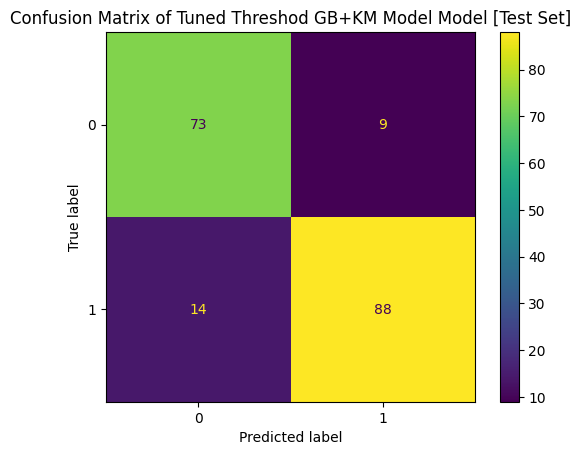

In [206]:
plot_confusion_matrix(
    ttcv, "Tuned Threshod GB+KM Model", X_test, Y_test
)

In [207]:
log_error("Opt GB+KM+TTCV Model", ttcv_train_error.values(), "train", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_cv_errors.values(), "cv", perf_df)
log_error("Opt GB+KM+TTCV Model", ttcv_test_error.values(), "test", perf_df)

In [208]:
perf_df

,train_accuracy,train_recall,train_precision,cv_accuracy,cv_recall,cv_precision,test_accuracy,test_recall,test_precision
Base Model,0.553134,1.0,0.553134,0.553136,1.0,0.553136,0.554348,1.0,0.554348
Lg_Model,0.858311,0.884236,0.862981,0.85007,0.871786,0.859979,0.88587,0.931373,0.87156
Dt_Model,0.854223,0.844828,0.886305,0.836455,0.857061,0.852289,0.820652,0.794118,0.870968
Rf_Model,0.862398,0.908867,0.852194,0.854198,0.908702,0.840878,0.831522,0.901961,0.814159
Gb_Model,0.953678,0.96798,0.949275,0.855549,0.869347,0.870428,0.891304,0.901961,0.901961
preOpt GB Model,0.871935,0.938424,0.846667,0.852828,0.908732,0.838948,0.842391,0.901961,0.828829
Opt GB Model,0.859673,0.940887,0.828633,0.843276,0.921018,0.819337,0.820652,0.921569,0.789916
Opt GB+KM Model,0.959128,0.96798,0.958537,0.830994,0.852123,0.845099,0.88587,0.892157,0.90099
Opt GB+KM+TTCV Model,0.956403,0.948276,0.972222,0.840555,0.864288,0.850758,0.875,0.862745,0.907216


### Retrain the whole dataset 

Gb_model and lg_model has the best performance for all result, although Lg_model has higher recall value , but Gb_model has a more balance result , so im going to be choosing GB_model as my finial model 

In [123]:
gb_pipeline.fit(x, y)

,steps,"[('columntransformer', ...), ('gradientboostingclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [124]:
get_errors(gb_pipeline, x, y)

{'accuracy': 0.934640522875817,
 'recall': 0.9566929133858267,
 'precision': 0.9274809160305344}

## Save Model

In [125]:
import joblib

In [126]:
joblib.dump(gb_pipeline,"../../models/heart_advance_model_v1.pk1")

['../../models/heart_advance_model_v1.pk1']

#### Load Model

In [128]:
model = joblib.load("../../models/heart_advance_model_v1.pk1")

In [129]:
get_errors(model,x,y)

{'accuracy': 0.934640522875817,
 'recall': 0.9566929133858267,
 'precision': 0.9274809160305344}

In [130]:
df.iloc[50:60]

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,max_hr,exercise_angina,old_peak,st_slope,heartdisease
50,50,M,ASY,130,233,0,Normal,121,Y,2.0,Flat,1
51,47,F,ASY,120,205,0,Normal,98,Y,2.0,Flat,1
52,45,M,ATA,140,224,1,Normal,122,N,0.0,Up,0
53,41,F,ATA,130,245,0,Normal,150,N,0.0,Up,0
54,52,F,ASY,130,180,0,Normal,140,Y,1.5,Flat,0
55,51,F,ATA,160,194,0,Normal,170,N,0.0,Up,0
56,31,M,ASY,120,270,0,Normal,153,Y,1.5,Flat,1
57,58,M,NAP,130,213,0,ST,140,N,0.0,Flat,1
58,54,M,ASY,150,365,0,ST,134,N,1.0,Up,0
59,52,M,ASY,112,342,0,ST,96,Y,1.0,Flat,1


In [131]:
pd.DataFrame(model.predict(x.iloc[50:60]))

,0
0,1
1,1
2,0
3,0
4,1
5,0
6,1
7,1
8,0
9,1
